In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

In [2]:
import pandas as pd

df = pd.read_csv(
    "perfumes.csv"
)

In [8]:
df.shape

(131930, 59)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 59 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        131930 non-null  int64  
 1   slug                      131930 non-null  object 
 2   name                      131930 non-null  object 
 3   brand                     131930 non-null  object 
 4   year                      107797 non-null  float64
 5   collection                55867 non-null   object 
 6   gender                    131930 non-null  object 
 7   url                       131930 non-null  object 
 8   rating_avg                131930 non-null  float64
 9   vote_count                131930 non-null  int64  
 10  rating_b1                 131930 non-null  int64  
 11  rating_b2                 131930 non-null  int64  
 12  rating_b3                 131930 non-null  int64  
 13  rating_b4                 131930 non-null  i

In [11]:
df.head(3)

,id,slug,name,brand,year,collection,gender,url,rating_avg,vote_count,rating_b1,rating_b2,rating_b3,rating_b4,rating_b5,longevity_avg,longevity_b1,longevity_b2,longevity_b3,longevity_b4,longevity_b5,sillage_avg,sillage_b1,sillage_b2,sillage_b3,sillage_b4,price_value_avg,price_value_b1,price_value_b2,price_value_b3,price_value_b4,price_value_b5,have,had,want,perceived_female,perceived_female_leaning,perceived_unisex,perceived_male_leaning,perceived_male,winter,spring,summer,autumn,day,night,people,magnitude,compound_magnitude,recent_magnitude,last_comment_at,scraped_at,accords,notes_top,notes_middle,notes_base,notes_flat,perfumers,description
0,1,Azzaro/Orange-Tonic,Orange Tonic,Azzaro,NaN,TONIC,female,https://www.fragrantica.com/perfume/Azzaro/Ora...,3.4421,95,3,28,1,50,13,2.8696,4,5,7,4,3,2.4444,5,10,7,5,3.4444,0,2,2,4,1,68,103,148,6,1,2,0,1,8,17,32,12,47,5,95.0,569,91,77,1775717654,1780102667,citrus:100|fresh spicy:47|green:41|sweet:33|ar...,Orange|Bergamot|Basil|Grapefruit|Green Notes|M...,Honeysuckle|Blueberry|Flowers|Lily-of-the-Vall...,Honey|Amber|Cedar|Musk,NaN,Nathalie Feisthauer,Orange Tonic by Azzaro is a Floral Green fragr...
1,3,Givenchy/Amarige,Amarige,Givenchy,1991.0,AMARIGE,female,https://www.fragrantica.com/perfume/Givenchy/A...,3.9053,9072,129,1711,335,3612,3285,3.9315,51,99,644,1254,800,2.9491,115,791,1291,865,3.2381,45,158,661,325,117,8519,8036,3653,1297,139,59,5,11,1906,1672,854,2129,2064,1990,9072.0,29317,3993,3260,1777937291,1780064964,white floral:100|sweet:52|yellow floral:47|woo...,Orange Blossom|Peach|Plum|Neroli|Brazilian Ros...,Tuberose|Mimosa|Gardenia|Ylang-Ylang|Jasmine|B...,Sandalwood|Amber|Woody Notes|Vanilla|Musk|Tonk...,NaN,Dominique Ropion,Amarige by Givenchy is a Floral fragrance for ...
2,4,Givenchy/Organza,Organza,Givenchy,1996.0,ORGANZA BY GIVENCHY,female,https://www.fragrantica.com/perfume/Givenchy/O...,3.9587,11565,77,1926,409,5139,4014,3.8022,63,150,792,1432,667,2.7327,215,1125,1509,626,3.0901,48,173,682,236,71,11302,9871,6008,1158,151,71,8,5,2947,1221,811,3077,2051,3146,11565.0,38899,4373,3401,1778091134,1780064758,white floral:100|fresh spicy:33|woody:30|vanil...,Nutmeg|Gardenia|African Orange Flower|Green No...,Tuberose|Jasmine|Honeysuckle|Iris|Peony|Mace,Vanilla|Amber|Woodsy Notes|Guaiac Wood|Virgini...,NaN,Sophie Labbé,Organza by Givenchy is a Oriental Floral fragr...


Quick summary 

In [12]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 131,930
Columns: 59


Misssing Values Analysis

In [13]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
)

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).head(20)

,Missing Count,Missing %
accords,2769,2.10
autumn,0,0.00
brand,0,0.00
collection,76063,57.65
compound_magnitude,0,0.00
day,0,0.00
description,0,0.00
gender,0,0.00
had,0,0.00
have,0,0.00


In [14]:
df.duplicated(
    subset=["name", "brand"]
).sum()

1417

In [19]:
duplicates = df[
    df.duplicated(
        subset=["name", "brand"],
        keep=False
    )
]

duplicates.sort_values(
    ["brand", "name"]
).head(20)

,id,slug,name,brand,year,collection,gender,url,rating_avg,vote_count,rating_b1,rating_b2,rating_b3,rating_b4,rating_b5,longevity_avg,longevity_b1,longevity_b2,longevity_b3,longevity_b4,longevity_b5,sillage_avg,sillage_b1,sillage_b2,sillage_b3,sillage_b4,price_value_avg,price_value_b1,price_value_b2,price_value_b3,price_value_b4,price_value_b5,have,had,want,perceived_female,perceived_female_leaning,perceived_unisex,perceived_male_leaning,perceived_male,winter,spring,summer,autumn,day,night,people,magnitude,compound_magnitude,recent_magnitude,last_comment_at,scraped_at,accords,notes_top,notes_middle,notes_base,notes_flat,perfumers,description
88784,90796,100-Bon/Patchouli-Labdanum,Patchouli & Labdanum,100 Bon,2020.0,Les eaux,unisex,https://www.fragrantica.com/perfume/100-Bon/Pa...,4.0000,4,0,0,0,4,0,3.0000,0,0,1,0,0,1.0000,1,0,0,0,3.0000,0,0,1,0,0,12,3,21,0,0,0,2,1,4,1,1,4,4,2,4.0,63,37,35,1712315915,1780151870,woody:100|patchouli:74|earthy:52|amber:46|warm...,Tonka Bean,Patchouli|Haitian Vetiver|Virginia Cedar,Labdanum|Sandalwood|Amyris|Benzoin,NaN,Jacques Flori,Patchouli & Labdanum by 100 Bon is a Oriental ...
92258,94336,100-Bon/Patchouli-Labdanum,Patchouli & Labdanum,100 Bon,NaN,Eaux de Cologne,unisex,https://www.fragrantica.com/perfume/100-Bon/Pa...,4.5000,4,0,0,0,2,2,3.2500,0,0,3,1,0,2.6667,0,2,0,1,4.3333,0,0,0,2,1,10,0,14,0,0,1,3,1,4,1,0,4,3,1,4.0,50,32,31,0,1780156829,woody:100|patchouli:97|amber:65|earthy:58|warm...,NaN,Patchouli|Vetiver,Labdanum|Vanilla,NaN,NaN,Patchouli & Labdanum by 100 Bon is a fragrance...
88778,90789,100-Bon/Soleil-Ambre,Soleil & Ambre,100 Bon,2018.0,Les eaux,unisex,https://www.fragrantica.com/perfume/100-Bon/So...,4.1765,51,1,1,6,23,20,2.6000,4,10,10,6,0,1.7931,9,17,3,0,3.8333,0,1,9,14,6,137,18,106,16,8,9,0,0,7,21,27,13,29,4,51.0,439,272,261,1773143415,1780106491,white floral:100|floral:38|citrus:37|sweet:34|...,Coconut|Bergamot|Mandarin,Tiare Flower|Frangipani|Jasmine,Amber|Musk|Sandalwood|Vetiver,NaN,Karine Vinchon Spehner,Soleil & Ambre by 100 Bon is a Floral fragranc...
92259,94337,100-Bon/Soleil-Ambre,Soleil & Ambre,100 Bon,2018.0,Les Eaux,unisex,https://www.fragrantica.com/perfume/100-Bon/So...,4.1000,10,0,0,1,7,2,2.7778,0,4,3,2,0,1.6667,3,6,0,0,4.1250,0,0,1,5,2,32,6,10,5,1,4,0,0,1,4,8,5,8,1,10.0,74,60,58,0,1780148562,citrus:100|white floral:100|fresh:60|floral:20...,Citrus,Jasmine,NaN,NaN,NaN,Soleil & Ambre by 100 Bon is a fragrance for w...
33674,34473,1000-Flowers/Narcotic-Flowers,Narcotic Flowers,1000 Flowers,2005.0,Discontinued,unisex,https://www.fragrantica.com/perfume/1000-Flowe...,3.8667,45,0,9,3,18,15,3.0000,2,5,7,5,2,2.2273,3,12,6,1,3.2500,1,2,3,5,1,29,17,66,8,3,3,0,0,5,15,9,10,13,11,45.0,249,11,5,1654638801,1780115556,white floral:100|floral:45|tuberose:38|amber:3...,NaN,NaN,NaN,Jasmine|Tuberose|French orange flower|Absinthe...,Jessica Buchanan,Narcotic Flowers by 1000 Flowers is a Floral f...
93390,95487,1000-Flowers/Narcotic-Flowers,Narcotic Flowers,1000 Flowers,2019.0,NaN,unisex,https://www.fragrantica.com/perfume/1000-Flowe...,4.0000,2,0,0,0,2,0,3.5000,0,0,1,1,0,2.0000,0,2,0,0,4.0000,0,0,1,0,1,6,1,12,1,0,2,0,0,1,1,0,1,1,1,2.0,40,29,28,0,1780161877,white floral:100|citrus:86|aquatic:84|yellow f...,Lime|Water Notes|Absinthe|Green Mandarin,Orange Blossom|Ylang Ylang|Jasmine Sambac|Magn...,Ambroxan|Sandalwood|Cedarwood|Patchouli,NaN,Jessica Buchanan,Narcotic Flowers by 1000 Flowers is a Floral f...
28202,28757,10th-Avenue-Karl-Antony/10th-Avenue-Sport,10th Avenue Sport,10th Avenue Karl Antony,NaN,NaN,female,https://www.fragrantica.com/perfume/10th-Avenu...,4.0000,1,0,0,0,1,0,2.0000,1,0,1,0,0,2.6667,1,0,1,1,0.0000,0,0,0,0,0,6,1,8,0,0,0,0,0,0,0,0,1,0,0,1.0,33,4,3,0,1780165149,citrus:100|fruity:44|violet:39|floral:39|powde...,Mandarin Orange|Orange|Bergamot|elemi,Violet|Rose|Black Currant|Jasmine|Cyclamen|Ora...,Vanilla|Cedar|Sandalwood|Amber|White Musk,NaN,NaN,10th Avenue Sport by 10th Avenue Karl Antony i...
28209,28764,10th-Avenue-Karl-Antony/10th-Avenue-Sport,10th Avenue Sport,1

In [15]:
df.select_dtypes(
    include=np.number
).columns.tolist()

['id',
 'year',
 'rating_avg',
 'vote_count',
 'rating_b1',
 'rating_b2',
 'rating_b3',
 'rating_b4',
 'rating_b5',
 'longevity_avg',
 'longevity_b1',
 'longevity_b2',
 'longevity_b3',
 'longevity_b4',
 'longevity_b5',
 'sillage_avg',
 'sillage_b1',
 'sillage_b2',
 'sillage_b3',
 'sillage_b4',
 'price_value_avg',
 'price_value_b1',
 'price_value_b2',
 'price_value_b3',
 'price_value_b4',
 'price_value_b5',
 'have',
 'had',
 'want',
 'perceived_female',
 'perceived_female_leaning',
 'perceived_unisex',
 'perceived_male_leaning',
 'perceived_male',
 'winter',
 'spring',
 'summer',
 'autumn',
 'day',
 'night',
 'people',
 'magnitude',
 'compound_magnitude',
 'recent_magnitude',
 'last_comment_at',
 'scraped_at']

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,131930.0,6.741285e+04,3.888165e+04,1.000000e+00,3.369225e+04,6.750550e+04,1.011288e+05,1.345300e+05
year,107797.0,2.015636e+03,1.646255e+01,2.000000e+01,2.014000e+03,2.019000e+03,2.023000e+03,2.027000e+03
rating_avg,131930.0,3.479748e+00,1.431624e+00,0.000000e+00,3.500000e+00,3.975100e+00,4.242400e+00,5.000000e+00
vote_count,131930.0,1.616010e+02,8.599450e+02,0.000000e+00,2.000000e+00,1.100000e+01,6.100000e+01,3.569500e+04
rating_b1,131930.0,3.622565e+00,2.667394e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.875000e+03
rating_b2,131930.0,1.884678e+01,1.151706e+02,0.000000e+00,0.000000e+00,1.000000e+00,6.000000e+00,9.529000e+03
rating_b3,131930.0,1.430529e+01,7.339357e+01,0.000000e+00,0.000000e+00,1.000000e+00,5.000000e+00,3.324000e+03
rating_b4,131930.0,6.029296e+01,3.048647e+02,0.000000e+00,0.000000e+00,4.000000e+00,2.300000e+01,1.490500e+04
rating_b5,131930.0,6.453345e+01,3.894496e+02,0.000000e+00,1.000000e+00,4.000000e+00,2.200000e+01,1.938700e+04
longevity_avg,131930.0,2.654820e+00,1.392694e+00,0.000000e+00,2.300000e+00,3.000000e+00,3.562375e+00,5.000000e+00


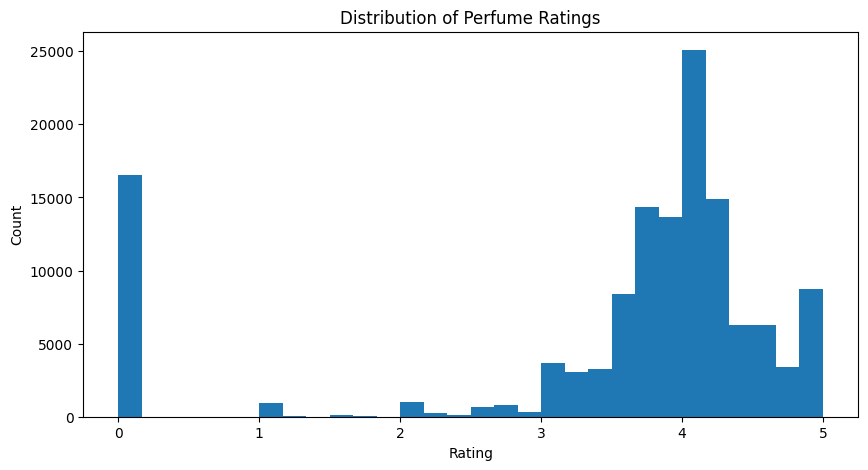

In [21]:
plt.figure(figsize=(10,5))

plt.hist(
    df["rating_avg"],
    bins=30
)

plt.title("Distribution of Perfume Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [22]:
df[df["rating_avg"] == 0].shape

(16551, 59)

In [23]:
df[df["rating_avg"] == 0][["name","brand","vote_count"]].head(20)

,name,brand,vote_count
915,Cobice,Abinoam,0
2060,Etre Special Edition,Lancetti,0
2183,Livingstone Traveller Fragrance - Cape Town,Promoparf Exclusive,0
2184,Livingstone Traveller Fragrance - Kalahari,Promoparf Exclusive,0
3603,Cafe del Mar no 1 Men,Createurs Cosmetiques,0
3666,Cool Instinct,Airness,0
4751,Memories,JoAnne Bassett,0
5012,Mandorla,Deborah,0
5029,Fabi Per Lei,Fabi,0
5074,Lustrous Fire,Antica Farmacista,0


remove vote_count = 0 and rating_avg = 0

In [24]:
df_rated = df[
    (df["vote_count"] > 0) &
    (df["rating_avg"] > 0)
].copy()

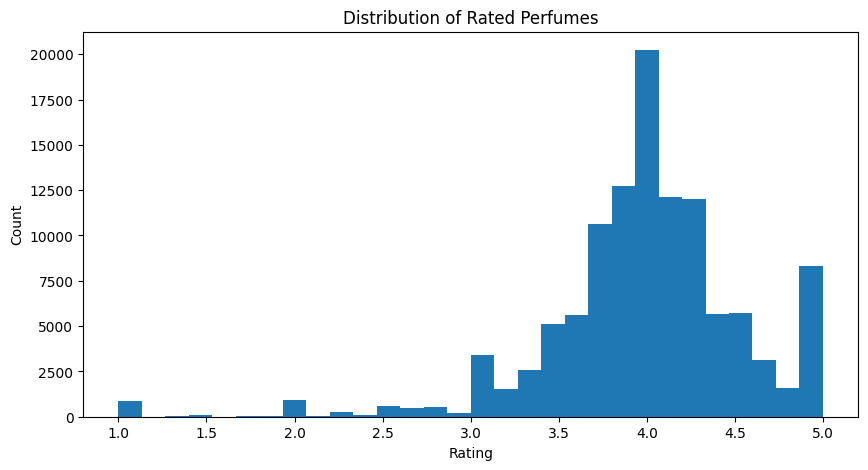

In [25]:
plt.figure(figsize=(10,5))

plt.hist(
    df_rated["rating_avg"],
    bins=30
)

plt.title("Distribution of Rated Perfumes")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [33]:
df_model = df[
    df["vote_count"] >= 50
].copy()

In [27]:
df["vote_count"].describe(
    percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]
)

count    131930.000000
mean        161.601046
std         859.945035
min           0.000000
25%           2.000000
50%          11.000000
75%          61.000000
90%         259.000000
95%         608.000000
99%        2755.000000
max       35695.000000
Name: vote_count, dtype: float64

In [28]:
for threshold in [5,10,20,50,100]:
    print(
        threshold,
        len(df[df["vote_count"] >= threshold])
    )

5 85591
10 69990
20 54828
50 36732
100 25141


median votes = 11 and 75th percentile = 61, this means most perfumes have very few votes.

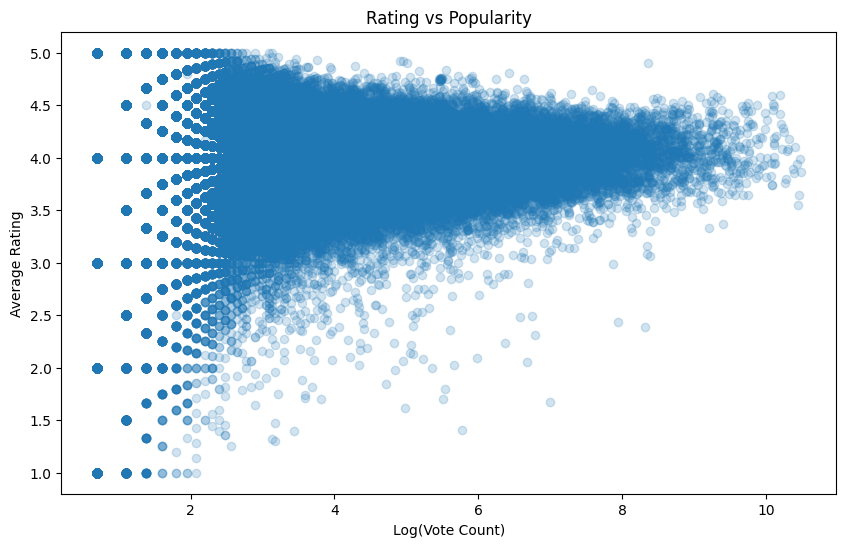

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    np.log1p(df_rated["vote_count"]),
    df_rated["rating_avg"],
    alpha=0.2
)

plt.xlabel("Log(Vote Count)")
plt.ylabel("Average Rating")
plt.title("Rating vs Popularity")

plt.show()

### Top rated perfumes

In [30]:
top_perfumes = (
    df_model
    .sort_values(
        "rating_avg",
        ascending=False
    )
)

top_perfumes[
    [
        "name",
        "brand",
        "rating_avg",
        "vote_count"
    ]
].head(20)

,name,brand,rating_avg,vote_count
77118,Darley,Assaf,5.0000,22
62432,Bracelets Of Kisra,Jaber & Kindi,5.0000,21
126828,Silent Fury,Maison Martin Margiela,4.9583,24
120960,Rose Eau de Toilette,L'Occitane en Provence,4.9545,22
124785,Flux,Voce di Sensi,4.9500,20
48669,La Symphonie,Claude Marsal Parfums,4.9355,31
696,Le Parfum,Mugler,4.9286,42
128724,Gladius,Nusuk,4.9259,135
104842,LV x TM Spell On You,Louis Vuitton,4.9220,141
40748,Accordes Celebrare,O Boticário,4.9130,23


In [31]:
df["accords"].dropna().iloc[0]

'citrus:100|fresh spicy:47|green:41|sweet:33|aromatic:31|fruity:27|white floral:26|honey:16'

In [32]:
df["notes_top"].dropna().iloc[0]

'Orange|Bergamot|Basil|Grapefruit|Green Notes|Mint|Lemon'

Create Accord Table

In [34]:
accords_series = (
    df["accords"]
    .dropna()
    .str.split("|")
    .explode()
)

accords_series.head()

0        citrus:100
0    fresh spicy:47
0          green:41
0          sweet:33
0       aromatic:31
Name: accords, dtype: object

In [35]:
accord_df = accords_series.str.split(
    ":",
    expand=True
)

accord_df.columns = [
    "accord",
    "strength"
]

accord_df["strength"] = (
    accord_df["strength"]
    .astype(float)
)

accord_df.head()

,accord,strength
0,citrus,100.0
0,fresh spicy,47.0
0,green,41.0
0,sweet,33.0
0,aromatic,31.0


Most Common Accords

In [36]:
accord_df["accord"].value_counts().head(20)

accord
woody           81432
powdery         62885
sweet           60625
citrus          59969
aromatic        54606
fresh spicy     47271
floral          46586
amber           45478
warm spicy      45319
fruity          43222
musky           41154
white floral    39497
vanilla         34562
fresh           33478
green           29755
rose            25617
earthy          19049
animalic        18242
balsamic        18162
patchouli       14822
Name: count, dtype: int64

Strongest Average Accords

In [40]:
accord_counts = (
    accord_df["accord"]
    .value_counts()
)

common_accords = accord_counts[
    accord_counts >= 500
].index

filtered_accords = accord_df[
    accord_df["accord"].isin(common_accords)
]

In [41]:
filtered_accords.groupby(
    "accord"
)["strength"].mean().sort_values(
    ascending=False
).head(20)

accord
citrus          67.283046
white floral    66.380358
woody           65.828360
oud             64.537599
fruity          64.469044
marine          62.832640
cherry          61.244038
amber           61.021549
vanilla         60.408223
leather         59.461005
coconut         59.025696
rose            59.020182
coffee          58.274931
warm spicy      57.098281
tobacco         56.644556
floral          56.229189
aromatic        56.065597
lavender        55.860725
iris            55.554288
honey           55.069513
Name: strength, dtype: float64

In [39]:
accord_df["accord"].value_counts().head(20)

accord
woody           81432
powdery         62885
sweet           60625
citrus          59969
aromatic        54606
fresh spicy     47271
floral          46586
amber           45478
warm spicy      45319
fruity          43222
musky           41154
white floral    39497
vanilla         34562
fresh           33478
green           29755
rose            25617
earthy          19049
animalic        18242
balsamic        18162
patchouli       14822
Name: count, dtype: int64

#### Which Accords are associated with higher ratings?

In [42]:
accords_expanded = (
    df_model[
        ["id","rating_avg","accords"]
    ]
    .dropna()
    .copy()
)

accords_expanded["accords"] = (
    accords_expanded["accords"]
    .str.split("|")
)

accords_expanded = accords_expanded.explode(
    "accords"
)

In [43]:
accords_expanded["accord"] = (
    accords_expanded["accords"]
    .str.split(":")
    .str[0]
)

In [44]:
accord_rating = (
    accords_expanded
    .groupby("accord")
    .agg(
        perfumes=("id","count"),
        avg_rating=("rating_avg","mean")
    )
)

In [45]:
accord_rating = accord_rating[
    accord_rating["perfumes"] >= 100
]

In [53]:
accord_rating.sort_values(
    "avg_rating",
    ascending=False
).head(20)

,perfumes,avg_rating
accord,,
cinnamon,1269,4.070750
tobacco,1209,4.063369
rum,447,4.055792
oud,2065,4.041402
whiskey,204,4.041056
balsamic,5055,4.022681
amber,12512,4.014479
smoky,2108,4.007962
leather,3244,4.007883


In [49]:
accord_rating_1000 = accord_rating[
    accord_rating["perfumes"] >= 1000
].copy()

In [50]:
accord_rating_1000.sort_values(
    "perfumes",
    ascending=False
).head(20)

,perfumes,avg_rating
accord,,
woody,24314,3.975912
sweet,18389,3.964155
powdery,18271,3.969276
citrus,16843,3.959640
aromatic,15691,3.983143
fresh spicy,13496,3.984164
floral,13471,3.934924
fruity,13393,3.928063
warm spicy,13110,4.004504


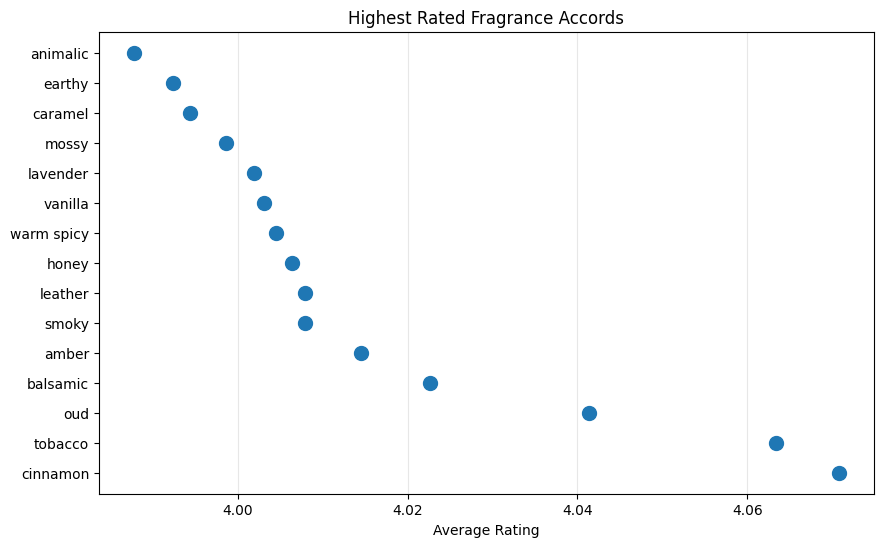

In [51]:
top_accords = (
    accord_rating_1000
    .sort_values("avg_rating", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

plt.scatter(
    top_accords["avg_rating"],
    top_accords.index,
    s=100
)

plt.xlabel("Average Rating")
plt.title("Highest Rated Fragrance Accords")

plt.grid(axis="x", alpha=0.3)

plt.show()

### Gender Distribution

gender
unisex    57820
female    39080
male      17762
Name: count, dtype: int64


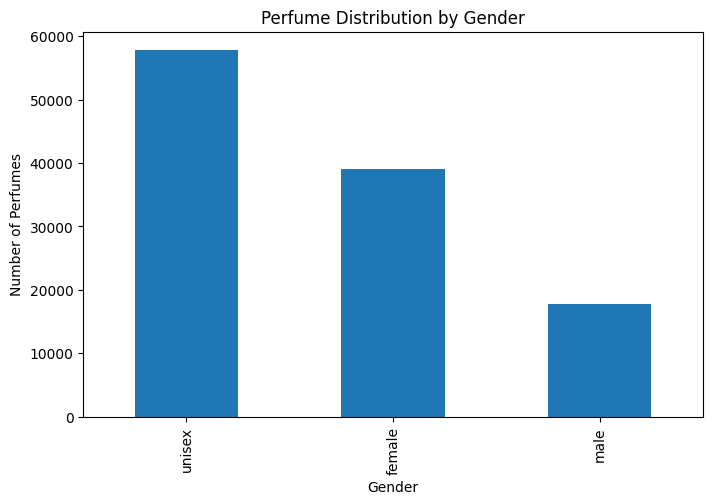

In [54]:
gender_counts = df_rated["gender"].value_counts()

print(gender_counts)

plt.figure(figsize=(8,5))

gender_counts.plot(
    kind="bar"
)

plt.title("Perfume Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Perfumes")

plt.show()

##### Release Year Trend

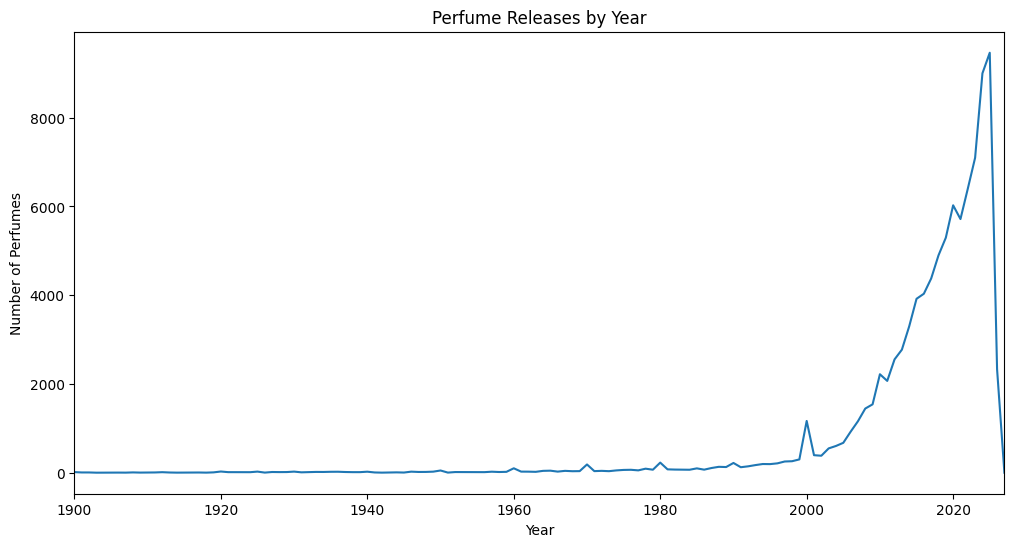

In [61]:
plt.figure(figsize=(12,6))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.xlim(year_counts.index.min(), year_counts.index.max())

plt.title("Perfume Releases by Year")
plt.xlabel("Year")
plt.ylabel("Number of Perfumes")

plt.show()

##### Top Brands

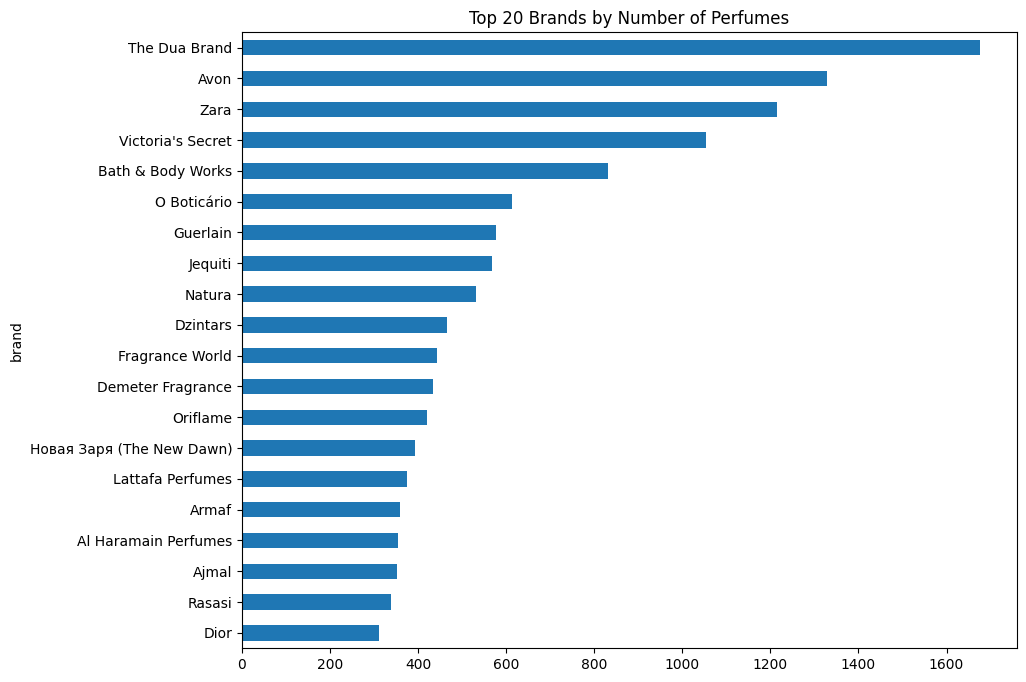

In [56]:
top_brands = (
    df_rated["brand"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))

top_brands.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Brands by Number of Perfumes")

plt.show()

##### Highest Rated Brands

In [57]:
brand_stats = (
    df_model
    .groupby("brand")
    .agg(
        perfumes=("id","count"),
        avg_rating=("rating_avg","mean")
    )
)

brand_stats = brand_stats[
    brand_stats["perfumes"] >= 20
]

brand_stats.sort_values(
    "avg_rating",
    ascending=False
).head(20)

,perfumes,avg_rating
brand,,
Arabian Oud,60,4.425338
Abdul Samad Al Qurashi,29,4.403672
Ahmed Al Maghribi,26,4.355381
Arabiyat Prestige,32,4.347738
Ibraheem AlQurashi,24,4.336671
Ermenegildo Zegna,39,4.325056
Areej Le Doré,58,4.277833
Louis Vuitton,53,4.269879
Prin,20,4.264110
